# **Triển khai dự án Data Science - Project 1 - PreProcessing**


# **Business Understanding**
* **Bối cảnh:** Dữ liệu nhà ở được đăng bán trên Nhà Tốt.
* **Nhu cầu:**
  * *Người bán:* cần gợi ý giá hợp lý, không bị “hớ” → Đồng thời
cung cấp giá phù hợp cho người mua.
  * *Nền tảng/kiểm duyệt:* cần cảnh báo tin đăng bài bán nhà có
giá bất thường để xử lý.
* **Xác định vấn đề:**
  * *Mục tiêu/ vấn đề:*
    * Xây dựng mô hình dự đoán & gợi ý giá đăng bán hợp lý.
    * Phát hiện bất thường: bài đăng đưa giá quá thấp/quá cao.
  * *Xây dựng mô hình:*
    * Dự đoán giá.
    * Phát hiện bất thường.

In [ ]:
# [Đông Hy]

# **Import thư viện**

In [ ]:
# !pip install ydata_profiling

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
# from ydata_profiling import ProfileReport
import warnings
warnings.filterwarnings('ignore')

# **Đọc dữ liệu**

## *Xác định vị trí lưu trữ dữ liệu trong drive của mình*

In [ ]:
# from google.colab import drive
# drive.mount('/content/gdrive', force_remount=True)

In [ ]:
# # Gắn mốc tại đường dẫn thư mục lưu file dữ liệu (của ĐÔNG HY)
# %cd '/content/gdrive/MyDrive/Cung cap HV'

In [ ]:
# Gắn mốc tại đường dẫn thư mục lưu file dữ liệu (Của các anh em)
# %cd '/content/gdrive/MyDrive/Cung cap HV'

In [ ]:
# pwd  # Check đường dẫn

In [ ]:
# ls  # Xem danh sách file trong thư mục

## *Đọc dữ liệu*

In [ ]:
cd C:/DL07_Do_An/data_1

C:\DL07_Do_An\data_1


In [ ]:
# Đọc dữ liệu ở quận Bình Thạnh
df_bt=pd.read_csv('quan-binh-thanh.csv')
df_bt['quan']='Bình Thạnh'

# Đọc dữ liệu ở quận Gò Vấp
df_gv = pd.read_csv('quan-go-vap.csv')
df_gv['quan']='Gò Vấp'

# Đọc dữ liệu ở quận Phú Nhuận
df_pn = pd.read_csv('quan-phu-nhuan.csv')
df_pn['quan']='Phú Nhuận'

In [ ]:
# Gộp thành 1 DF duy nhất
df=pd.concat([df_bt,df_gv,df_pn], ignore_index=True)
print(f"Kích thước dữ liệu sau khi gộp: {df.shape}")

Kích thước dữ liệu sau khi gộp: (8273, 24)


In [ ]:
df.head(3)

,tieu_de,gia_ban,don_gia,dien_tich,dia_chi,mo_ta,dien_thoai,loai_hinh,dien_tich_dat,dien_tich_su_dung,...,tong_so_tang,tinh_trang_noi_that,huong_cua_chinh,dac_diem,chieu_ngang,chieu_dai,ma_can,ten_phan_khu_lo,bieu_do_gia,quan
0,🍀VÂN KIỀU AN CƯ🍀 40m2 - Hẻm Ô Tô - Gần mặt tiề...,"3,85 tỷ","106,94 triệu/m²",36 m²,"Đường Lê Quang Định, Phường 7, Quận Bình Thạnh...",🍀VÂN KIỀU AN CƯ🍀\n\n🏡 Nhà Lê Quang Định P5 – G...,NaN,"Nhà ngõ, hẻm",36 m²,NaN,...,2.0,Nội thất đầy đủ,NaN,Nhà nở hậu,4.5 m,8 m,NaN,NaN,"[134.04, 125.8, 125.8, 125.8, 138.64, 138.64, ...",Bình Thạnh
1,"9.xty,Nhà Hẻm Xe Hơi,Xây Mới Khu VIP giáp Phạm...","9,79 tỷ","157,90 triệu/m²",62 m²,"Đường Phạm Văn Đồng, Phường 13, Quận Bình Thạn...","CHỈ 9.XTY - NHÀ MỚI KENG,XE HƠI NGỦ NHÀ GIÁP B...",0909761320,"Nhà ngõ, hẻm",62 m²,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[133.33, 135.54, 130.95, 130.02, 130.02, 136.3...",Bình Thạnh
2,XE HƠI NGỦ TRONG NHÀ- NGANG 7M - HIẾM - NƠ TRA...,"7,2 tỷ","133,33 triệu/m²",54 m²,"Đường Nơ Trang Long, Phường 13, Quận Bình Thạn...",XE HƠI NGỦ TRONG NHÀ- NGANG 7M - HIẾM - NƠ TRA...,0909983786,"Nhà ngõ, hẻm",54 m²,NaN,...,2.0,Hoàn thiện cơ bản,NaN,Hẻm xe hơi,7 m,7.7 m,NaN,NaN,"[168.37, 168.37, 120.71, 120.71, 124.24, 124.5...",Bình Thạnh


In [ ]:
df.groupby('quan').count()

,tieu_de,gia_ban,don_gia,dien_tich,dia_chi,mo_ta,dien_thoai,loai_hinh,dien_tich_dat,dien_tich_su_dung,...,so_phong_ve_sinh,tong_so_tang,tinh_trang_noi_that,huong_cua_chinh,dac_diem,chieu_ngang,chieu_dai,ma_can,ten_phan_khu_lo,bieu_do_gia
quan,,,,,,,,,,,,,,,,,,,,,
Bình Thạnh,2575,2574,2574,2574,2665,2574,1585,2574,2574,1178,...,1914,1686,1367,350,1596,1867,1794,4,1,2665
Gò Vấp,4181,4179,4179,4179,4374,4179,1715,4179,4179,2088,...,3117,2918,2380,808,2868,3323,3287,10,22,4374
Phú Nhuận,1208,1208,1208,1208,1234,1208,659,1208,1208,488,...,946,897,685,163,743,916,889,11,2,1234


In [ ]:
df.columns

Index(['tieu_de', 'gia_ban', 'don_gia', 'dien_tich', 'dia_chi', 'mo_ta',
       'dien_thoai', 'loai_hinh', 'dien_tich_dat', 'dien_tich_su_dung',
       'gia_m2', 'giay_to_phap_ly', 'so_phong_ngu', 'so_phong_ve_sinh',
       'tong_so_tang', 'tinh_trang_noi_that', 'huong_cua_chinh', 'dac_diem',
       'chieu_ngang', 'chieu_dai', 'ma_can', 'ten_phan_khu_lo', 'bieu_do_gia',
       'quan'],
      dtype='object')

# **Data Understanding/ Acquire**
Dữ liệu được cung cấp sẵn gồm có 3 tập tin:

    quan-binh-thanh.csv,
    quan-go-vap.csv,
    quan-phu-nhuan.csv.


Các tập tin đã được tổng hợp lại, tạo thành bộ dữ liệu chứa thông tin về các căn nhà riêng lẻ đang được rao bán tại các Quận Bình Thạnh, Phú Nhuận, Gò Vấp ở Thành phố Hồ Chí Minh trên nền tảng Nhà Tốt.


Các thuộc tính trong bộ dữ liệu bao gồm:
|Tên cột|Ý nghĩa|
|-------|-------|
|tieu_de| Tiêu đề của bài đăng rao bán nhà.|
|gia_ban| Tổng giá bán của bất động sản (ví dụ: tỷ, triệu).|
|don_gia| Mức giá tính trên mỗi mét vuông.|
|dien_tich| Tổng diện tích sử dụng hoặc diện tích công nhận.|
|dia_chi| Địa chỉ chi tiết của căn nhà (bao gồm tên đường, phường và quận).|
|mo_ta| Nội dung mô tả chi tiết về đặc điểm, kết cấu, vị trí và các tiện ích xung quanh căn nhà.|
|dien_thoai| Số điện thoại liên hệ của người đăng tin.|
|loai_hinh| Loại hình bất động sản (ví dụ: Nhà ngõ, hẻm).|
|dien_tich_dat| Diện tích mặt bằng đất thực tế.|
|dien_tich_su_dung| Tổng diện tích sàn sử dụng của căn nhà.|
|gia_m2| Giá bán quy đổi ra đơn vị triệu/m2.|
|giay_to_phap_ly| Tình trạng giấy tờ của bất động sản (ví dụ: Đã có sổ).|
|so_phong_ngu| Số lượng phòng ngủ có trong nhà.|
|so_phong_ve_sinh| Số lượng nhà vệ sinh/WC.|
|tong_so_tang| Tổng số tầng của căn nhà.|
|tinh_trang_noi_that| Tình trạng bàn giao nội thất (ví dụ: Nội thất đầy đủ, hoàn thiện cơ bản).|
|huong_cua_chinh| Hướng chính của ngôi nhà.|
|dac_diem| Các đặc điểm nổi bật khác (ví dụ: Nhà nở hậu, hẻm xe hơi).|
|chieu_ngang| Chiều rộng mặt tiền của căn nhà.|
|chieu_dai| Chiều sâu/chiều dài của căn nhà.|
|ma_can| Mã số định danh của căn nhà (nếu có).|
|ten_phan_khu_lo| Tên phân khu hoặc lô đất (nếu có).|
|bieu_do_gia| Dữ liệu lịch sử biến động giá tại khu vực xung quanh trong 12 tháng tính đến thời điểm thu thập dữ liệu.|

# **EDA**

In [ ]:
# # Tạo profile
# profile = ProfileReport(df, title="Phân tích Bất Động Sản TP.HCM", explorative=True)
# # Hiển thị kết quả
# profile.to_notebook_iframe()

In [ ]:
# profile_=ProfileReport(df, title="Phân tích Bất Động Sản TP.HCM", explorative=True)
# profile_.to_file("EDA_Report.html")
# # Này thì thay vì in ra màn hình thì lưu file .html thui
# # File .html thì dễ đọc hơn là hiển thị ra trong cell
# # Được lưu trong chính folder gốc mà anh em đã mount ban đầu á

**Vấn đề cần chú ý**

|Variable|Issue|Type|
|--------|-----|----|
|Dataset| 20 (0.2%) duplicate rows|	Duplicates|
|so_phong_ngu| is highly overall correlated with so_phong_ve_sinh|	High correlation|
|so_phong_ve_sinh| is highly overall correlated with so_phong_ngu|	High correlation|
|loai_hinh| is highly imbalanced (60.1%)|Imbalance|
|giay_to_phap_ly| is highly imbalanced (96.8%)|	Imbalance|
|dac_diem| is highly imbalanced (66.1%)|	Imbalance|
|tieu_de| 309 (3.7%) missing values	|Missing|
|gia_ban| 312 (3.8%) missing values	|Missing|
|don_gia| 312 (3.8%) missing values	|Missing|
|dien_tich| 312 (3.8%) missing values	|Missing|
|mo_ta| 312 (3.8%) missing values	|Missing|
|dien_thoai| 4314 (52.1%) missing values	|Missing|
|loai_hinh| 312 (3.8%) missing values	|Missing|
|dien_tich_dat| 312 (3.8%) missing values|	Missing|
|dien_tich_su_dung| 4519 (54.6%) missing values	|Missing|
|gia_m2| 312 (3.8%) missing values|	Missing|
|giay_to_phap_ly| 813 (9.8%) missing values|	Missing|
|so_phong_ngu| 312 (3.8%) missing values|	Missing|
|so_phong_ve_sinh| 2296 (27.8%) missing values|	Missing|
|tong_so_tang| 2772 (33.5%) missing values|	Missing|
|tinh_trang_noi_that| 3841 (46.4%) missing values|	Missing|
|huong_cua_chinh| 6952 (84.0%) missing values	|Missing|
|dac_diem| 3066 (37.1%) missing values|	Missing|
|chieu_ngang| 2167 (26.2%) missing values|	Missing|
|chieu_dai| 2303 (27.8%) missing values|	Missing|
|ma_can| 8248 (99.7%) missing values|	Missing|
|ten_phan_khu_lo| 8248 (99.7%) missing values|	Missing|
|ma_can|unsupported type, check if it needs cleaning or further analysis|	Unsupported|
|ten_phan_khu_lo| unsupported type, check if it needs cleaning or further analysis	|Unsupported|

**Nhận xét kết quả EDA:**
* Ta thấy rõ 2 cột `ma_can` và `ten_phan_khu_lo` bị thiếu dữ liệu gần như ở toàn bộ các bài đăng, do đó hoàn toàn không đóng góp gì vào dữ liệu.
* Các cột `dien_tich_su_dung`, `tinh_trang_not_that`, `huong_cua_chinh` bị thiếu lượng dữ liệu tương đối lớn.
* Ba cột `tieu_de`, `dien_thoai`, `mo_ta` cũng không có tác động mạnh mẽ gì đến giá cả (theo mình là vậy).
* Dữ liệu có sự mất cân bằng - **imbalanced** nghiêm trọng và cần được xử lý.
* Cột `so_phong_ngu` và cột `so_phong_ve_sinh` tương quan mạnh mẽ nhau.
* Những cột `gia_ban`,`don_gia`, `gia_m2`, `dien_tich`, `dien_tich_dat`,
`chieu_ngang`, `chieu_dai`, `so_phong_ngu`, `so_phong_ve_sinh`, `tong_so_tang`chưa phải ở dạng số hoàn toàn, cần phải chuyển về dạng số thuần.

# **Data Cleaning**

In [ ]:
len(df)

8273

In [ ]:
df_1=df.copy()  # Tạo copy để có lỗi lầm gì gây hại cấu trúc df thì còn có cái sơ cua.

In [ ]:
df_1.columns

Index(['tieu_de', 'gia_ban', 'don_gia', 'dien_tich', 'dia_chi', 'mo_ta',
       'dien_thoai', 'loai_hinh', 'dien_tich_dat', 'dien_tich_su_dung',
       'gia_m2', 'giay_to_phap_ly', 'so_phong_ngu', 'so_phong_ve_sinh',
       'tong_so_tang', 'tinh_trang_noi_that', 'huong_cua_chinh', 'dac_diem',
       'chieu_ngang', 'chieu_dai', 'ma_can', 'ten_phan_khu_lo', 'bieu_do_gia',
       'quan'],
      dtype='object')

In [ ]:
'''
PA:
Mình bổ sung thêm một số feature cần loại bỏ là
don_gia và gia_m2 --> Do sẽ bị nội suy trực tiếp ra giá bán
dien_tich --> Do trùng lặp với dien_tich_dat
chieu_dai, chieu_ngang --> Do 2 thằng này nhân nhau thì cũng ra dien_tich_dat nên có thể bỏ

'''
cold_drop=['ma_can','ten_phan_khu_lo','tieu_de','dien_thoai','huong_cua_chinh', 'don_gia', 'dien_tich', 'gia_m2', 'chieu_dai']
df_1.drop(columns=cold_drop, inplace=True)
# Drop những cột mình cho là không cần thiết.
# ĐÂY LÀ THEO Ý KIẾN CỦA MÌNH, ANH EM HÃY XEM KĨ VÀ ĐÓNG GÓP NHÉ, ĐỂ CHÚNG TA CÓ THỂ ĐI ĐẾN QUYẾT ĐỊNH CHUNG NHA.

### **ANH EM MÌNH CÙNG BÀN BẠC THÊM VỀ PHẦN FEATURE SELECTION NHA**

In [ ]:
len(df_1)

8273

In [ ]:
df_1.head(2)

,gia_ban,dia_chi,mo_ta,loai_hinh,dien_tich_dat,dien_tich_su_dung,giay_to_phap_ly,so_phong_ngu,so_phong_ve_sinh,tong_so_tang,tinh_trang_noi_that,dac_diem,chieu_ngang,bieu_do_gia,quan
0,"3,85 tỷ","Đường Lê Quang Định, Phường 7, Quận Bình Thạnh...",🍀VÂN KIỀU AN CƯ🍀\n\n🏡 Nhà Lê Quang Định P5 – G...,"Nhà ngõ, hẻm",36 m²,NaN,Đã có sổ,2 phòng,2 phòng,2.0,Nội thất đầy đủ,Nhà nở hậu,4.5 m,"[134.04, 125.8, 125.8, 125.8, 138.64, 138.64, ...",Bình Thạnh
1,"9,79 tỷ","Đường Phạm Văn Đồng, Phường 13, Quận Bình Thạn...","CHỈ 9.XTY - NHÀ MỚI KENG,XE HƠI NGỦ NHÀ GIÁP B...","Nhà ngõ, hẻm",62 m²,NaN,NaN,4 phòng,NaN,NaN,NaN,NaN,NaN,"[133.33, 135.54, 130.95, 130.02, 130.02, 136.3...",Bình Thạnh


In [ ]:
df_1.columns

Index(['gia_ban', 'dia_chi', 'mo_ta', 'loai_hinh', 'dien_tich_dat',
       'dien_tich_su_dung', 'giay_to_phap_ly', 'so_phong_ngu',
       'so_phong_ve_sinh', 'tong_so_tang', 'tinh_trang_noi_that', 'dac_diem',
       'chieu_ngang', 'bieu_do_gia', 'quan'],
      dtype='object')

## Bóc Mô tả thêm dữ liệu

In [ ]:
KEYWORDS = {
    "duong_lon": [
        "đường lớn", "đại lộ", "mặt đường", "mặt tiền", "trục chính",
        "đường huyết mạch", "đường 8m", "đường 10m", "đường 12m",
        "đường 20m", "cao tốc", "quốc lộ", "trục đường chính"
    ],
    "vi_tri_dat": [
        "góc", "ngã tư", "ngã ba", "căn góc"
    ],
    "garage": [
        "gara", "garage", "đỗ xe"
    ],
    "san_vuon": [
        "sân vườn", "sân thượng", "ban công"
    ],
    "hai_mat_tien": [
        "2 mặt tiền", "hai mặt tiền", "3 mặt tiền"
    ],
    "view": [
        "view"
    ],
    "vi_tri_trung_tam": [
        "trung tâm", "vip", "cao cấp", "quận 1", "lõi đô thị", "quận 3", "bến thành"
    ],
    "truong_hoc": [
        "trường học", "đại học", "trường", "giáo dục"
    ],
    "san_bay": [
        "sân bay"
    ],
    "benh_vien": [
        "bệnh viện", "phòng khám", "y tế"
    ],
    "sieu_thi": [
        "siêu thị", "chợ", "mall", "shopping", "trung tâm thương mại",
        "vincom", "aeon mall", "lotte"
    ],
    "giao_thong": [
        "metro", "bến xe", "bus", "trạm sạc"
    ],
    "giai_tri": [
        "công viên", "thể thao", "khu vui chơi", "hồ bơi", "sân bóng"
    ],
    "dia_diem_dac_biet": [
        "phú mỹ hưng", "thủ thiêm", "sala", "vinhomes",
        "thảo điền", "an phú", "landmark", "saigon pearl"
    ]
}

In [ ]:
PATTERNS = {
    name: re.compile(
        r"(" + "|".join(re.escape(term) for term in terms) + r")",
        flags=re.IGNORECASE
    )
    for name, terms in KEYWORDS.items()
}

In [ ]:
for name, pattern in PATTERNS.items():
    df_1[name] = df_1["mo_ta"].fillna("").str.contains(pattern, regex=True)
df_1.drop('mo_ta', axis = 1, inplace = True)

## *Làm sạch các cột số*

In [ ]:
# Chuyển đổi các chuỗi thành số
def extract_number(text):
    if pd.isna(text): return np.nan
    res = re.findall(r'\d+\.?\d*', str(text).replace(',', '.'))
    return float(res[0]) if res else np.nan

def convert_price(price_str):
    if pd.isna(price_str): return np.nan
    price_str = str(price_str).lower().replace(',', '.')
    val = extract_number(price_str)
    if 'tỷ' in price_str: return val * 1e9
    if 'triệu' in price_str: return val * 1e6
    return val

In [ ]:
# chuyển đổi
cols_price=['gia_ban']
for col in cols_price:
    df_1[col] = df_1[col].apply(convert_price)

cols_numeric = ['dien_tich_dat', 'so_phong_ngu', 'so_phong_ve_sinh', 'tong_so_tang', 'chieu_ngang']
for col in cols_numeric:
    df_1[col] = df_1[col].apply(extract_number)

In [ ]:
df_1.head(2)

,gia_ban,dia_chi,loai_hinh,dien_tich_dat,dien_tich_su_dung,giay_to_phap_ly,so_phong_ngu,so_phong_ve_sinh,tong_so_tang,tinh_trang_noi_that,...,hai_mat_tien,view,vi_tri_trung_tam,truong_hoc,san_bay,benh_vien,sieu_thi,giao_thong,giai_tri,dia_diem_dac_biet
0,3.850000e+09,"Đường Lê Quang Định, Phường 7, Quận Bình Thạnh...","Nhà ngõ, hẻm",36.0,NaN,Đã có sổ,2.0,2.0,2.0,Nội thất đầy đủ,...,False,False,True,True,True,True,False,False,False,False
1,9.790000e+09,"Đường Phạm Văn Đồng, Phường 13, Quận Bình Thạn...","Nhà ngõ, hẻm",62.0,NaN,NaN,4.0,NaN,NaN,NaN,...,False,False,True,False,True,False,False,False,False,False


## *New Features*

In [ ]:
'''
PA: Ở đây mình sẽ sử dụng phường (tách từ địa chỉ) để phân định địa bàn thay vì quận
--> Phù hợp với thực tế
--> Thu nhỏ được khu vực có thể tăng tính chính xác
'''

'\nPA: Ở đây mình sẽ sử dụng phường (tách từ địa chỉ) để phân định địa bàn thay vì quận\n--> Phù hợp với thực tế\n--> Thu nhỏ được khu vực có thể tăng tính chính xác\n'

In [ ]:
df_1['phuong'] = df['dia_chi'].apply(
    lambda x: re.sub(r'\(','',re.split(',',re.search(r'\(.*?\)', x).group())[0]) if re.search(r'\(.*?\)', x) else np.nan)

df_1.drop(['quan', 'dia_chi'], axis = 1, inplace = True)

In [ ]:
'''
PA:
Ở đây mình dựa vào feature bieu_do_gia, lấy ra giá trị gần nhất (mức giá/m2 của khu vực lân cận mảnh đất đó)
--> Thể hiện độ hấp dẫn của khu vực đó trên thị trường
'''

'\nPA:\nỞ đây mình dựa vào feature bieu_do_gia, lấy ra giá trị gần nhất (mức giá/m2 của khu vực lân cận mảnh đất đó)\n--> Thể hiện độ hấp dẫn của khu vực đó trên thị trường\n'

In [ ]:
df_1['gia_m2_tham_khao'] = df_1.apply(
    lambda row: [float(i.strip().replace('[', '').replace(']', '')) for i in row['bieu_do_gia'].split(',')][-1]
    if row['bieu_do_gia'] != '[]' else np.nan, axis = 1)

df_1.drop('bieu_do_gia', axis = 1, inplace = True)

In [ ]:
len(df_1)

8273

## *Handle missing values*


In [ ]:
summary_missing = pd.DataFrame({
    'Số lượng thiếu': df_1.isnull().sum(),
    'Tỷ lệ (%)': (df_1.isnull().sum() * 100) / len(df)
})
print(summary_missing)

                     Số lượng thiếu  Tỷ lệ (%)
gia_ban                         312   3.771304
loai_hinh                       312   3.771304
dien_tich_dat                   312   3.771304
dien_tich_su_dung              4519  54.623474
giay_to_phap_ly                 813   9.827149
so_phong_ngu                    312   3.771304
so_phong_ve_sinh               2296  27.752931
tong_so_tang                   2772  33.506588
tinh_trang_noi_that            3841  46.428140
dac_diem                       3066  37.060317
chieu_ngang                    2167  26.193642
duong_lon                         0   0.000000
vi_tri_dat                        0   0.000000
garage                            0   0.000000
san_vuon                          0   0.000000
hai_mat_tien                      0   0.000000
view                              0   0.000000
vi_tri_trung_tam                  0   0.000000
truong_hoc                        0   0.000000
san_bay                           0   0.000000
benh_vien    

In [ ]:
# thiếu ~50%: dien_tich_su_dung, tinh_trang_noi_that
  # Loại bỏ vì dữ liệu không đủ
df_1.drop(columns=['dien_tich_su_dung'], inplace=True)

# thiếu 26% - 37%: chieu_ngang, chieu_dai, so_phong_ve_sinh, tong_so_tang, dac_diem
  # Điền bằng Median theo từng quận.
for col in ['so_phong_ve_sinh', 'tong_so_tang', 'so_phong_ngu', 'chieu_ngang', 'gia_m2_tham_khao']:
    df_1[col] = df_1.groupby('phuong')[col].transform(lambda x: x.fillna(x.median()))

# Cột phân loại (9.8% - 37%): giay_to_phap_ly, dac_diem, loai_hinh
  # Điền kiểu không rõ này nọ để mô hình học rằng là ồ chỗ này bị thiếu, có thể có vấn đề.
df_1['giay_to_phap_ly'] = df_1['giay_to_phap_ly'].fillna('Chưa xác định')
df_1['dac_diem'] = df_1['dac_diem'].fillna('Thông thường')
df_1['loai_hinh'] = df_1['loai_hinh'].fillna('Không rõ')
df_1['tinh_trang_noi_that'] = df_1['tinh_trang_noi_that'].fillna('Không rõ')

In [ ]:
len(df_1)

8273

In [ ]:
summary_missing = pd.DataFrame({
    'Số lượng thiếu': df_1.isnull().sum(),
    'Tỷ lệ (%)': (df_1.isnull().sum() * 100) / len(df)
})
print(summary_missing)

                     Số lượng thiếu  Tỷ lệ (%)
gia_ban                         312   3.771304
loai_hinh                         0   0.000000
dien_tich_dat                   312   3.771304
giay_to_phap_ly                   0   0.000000
so_phong_ngu                    312   3.771304
so_phong_ve_sinh                313   3.783392
tong_so_tang                    313   3.783392
tinh_trang_noi_that               0   0.000000
dac_diem                          0   0.000000
chieu_ngang                     312   3.771304
duong_lon                         0   0.000000
vi_tri_dat                        0   0.000000
garage                            0   0.000000
san_vuon                          0   0.000000
hai_mat_tien                      0   0.000000
view                              0   0.000000
vi_tri_trung_tam                  0   0.000000
truong_hoc                        0   0.000000
san_bay                           0   0.000000
benh_vien                         0   0.000000
sieu_thi     

In [ ]:
df_1.head(2)

,gia_ban,loai_hinh,dien_tich_dat,giay_to_phap_ly,so_phong_ngu,so_phong_ve_sinh,tong_so_tang,tinh_trang_noi_that,dac_diem,chieu_ngang,...,vi_tri_trung_tam,truong_hoc,san_bay,benh_vien,sieu_thi,giao_thong,giai_tri,dia_diem_dac_biet,phuong,gia_m2_tham_khao
0,3.850000e+09,"Nhà ngõ, hẻm",36.0,Đã có sổ,2.0,2.0,2.0,Nội thất đầy đủ,Nhà nở hậu,4.5,...,True,True,True,True,False,False,False,False,Phường Gia Định,140.91
1,9.790000e+09,"Nhà ngõ, hẻm",62.0,Chưa xác định,4.0,3.0,3.0,Không rõ,Thông thường,4.2,...,True,False,True,False,False,False,False,False,Phường Bình Lợi Trung,140.00


In [ ]:
len(df_1)

8273

# **Handle Outliers**

In [ ]:
# def remove_outliers_iqr(df, col):
#     Q1 = df[col].quantile(0.25)
#     Q3 = df[col].quantile(0.75)
#     IQR = Q3 - Q1
#     # Chỉ giữ lại dữ liệu nằm trong "vùng an toàn"
#     return df[(df[col] >= Q1 - 1.5 * IQR) & (df[col] <= Q3 + 1.5 * IQR)]

In [ ]:
# # Cắt bỏ outliers cho 2 biến dễ gây nhiễu nhất
# df_1 = remove_outliers_iqr(df_1, 'gia_ban')
# print(f"Số lượng sau khi 'trảm' Outliers: {len(df_1)} căn nhà")

# **Trực quan hóa dữ liệu (đã tiền xử lý)**

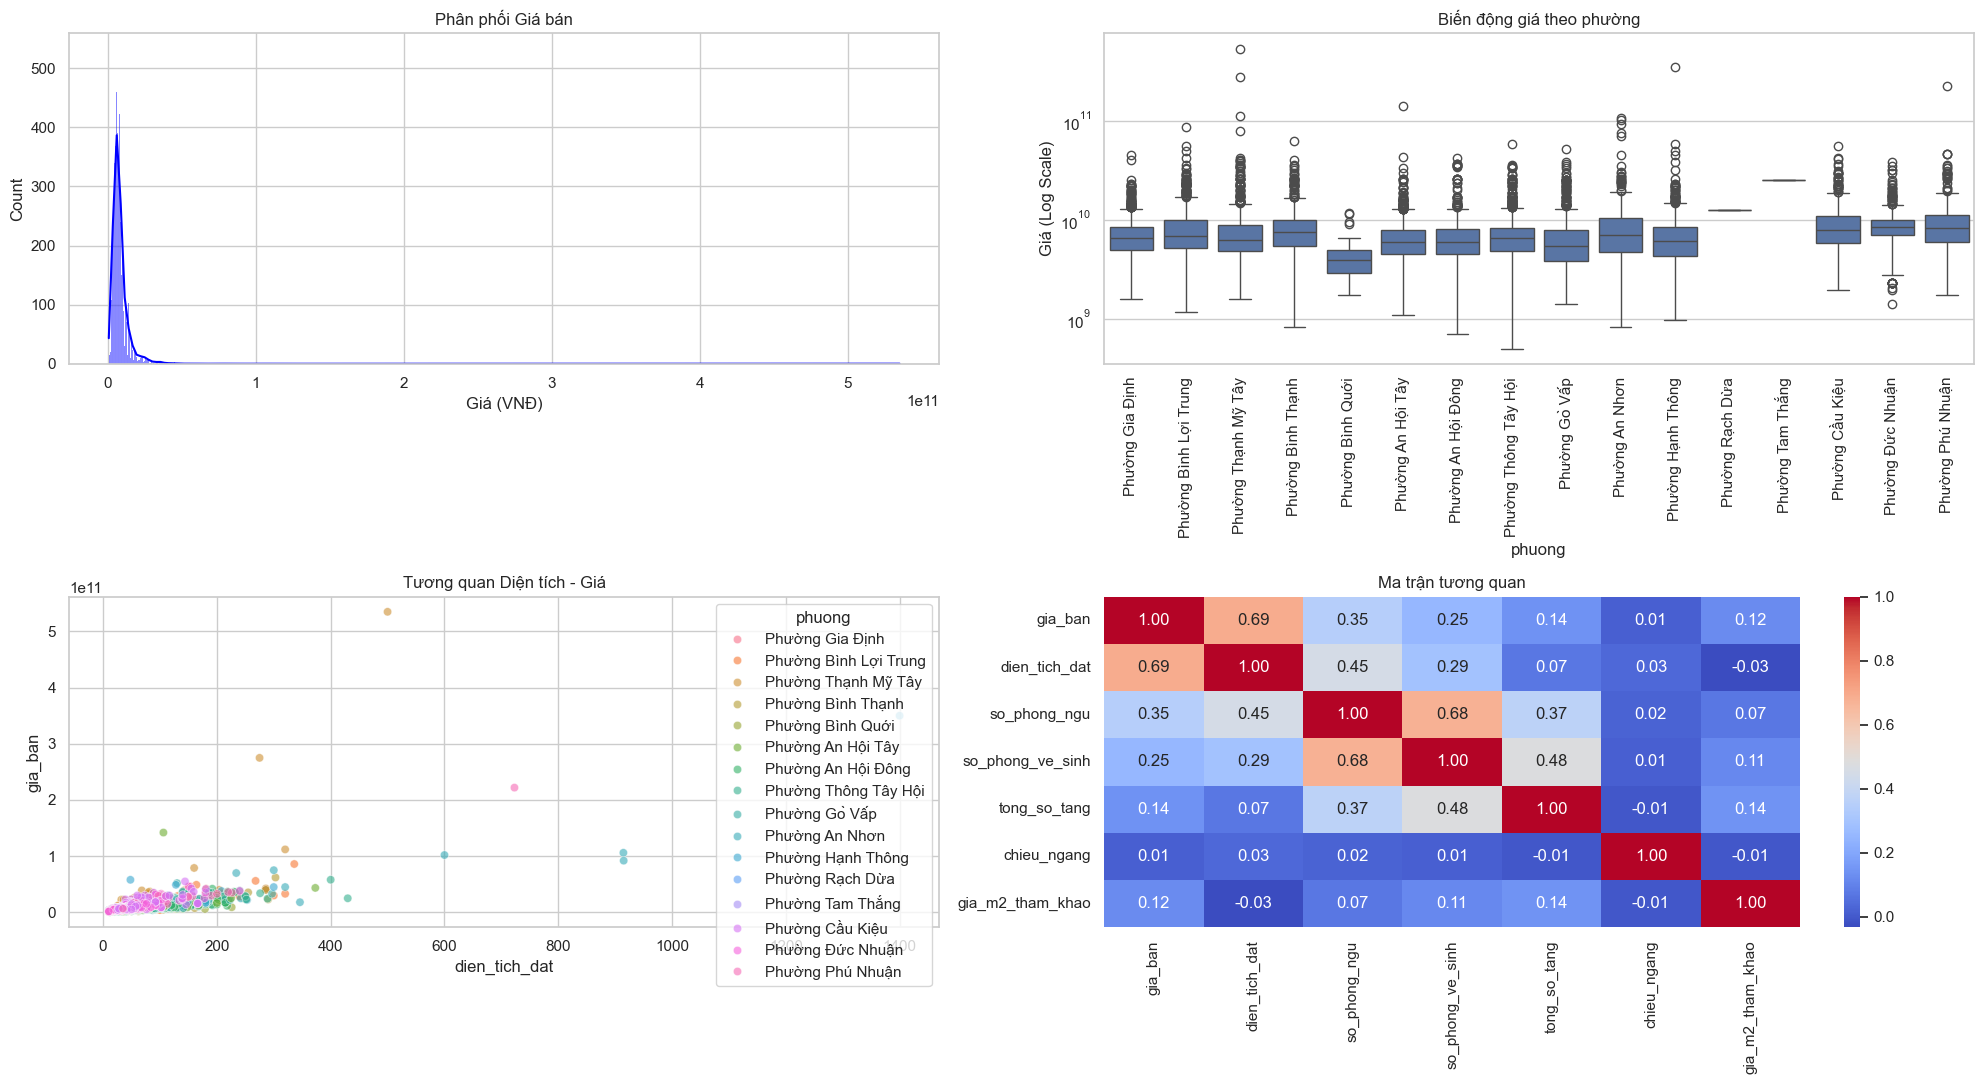

In [ ]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (20, 11)

# lưới biểu đồ 2x2
fig, axes = plt.subplots(2, 2)

# phân phối giá
sns.histplot(df_1['gia_ban'], kde=True, ax=axes[0, 0], color='blue')
axes[0, 0].set_title('Phân phối Giá bán')
axes[0, 0].set_xlabel('Giá (VNĐ)')

# giá theo phường
sns.boxplot(x='phuong', y='gia_ban', data=df_1, ax=axes[0, 1])
axes[0, 1].set_title('Biến động giá theo phường')
axes[0, 1].set_yscale('log') # Dùng thang log để dễ nhìn các hộp
axes[0, 1].set_ylabel('Giá (Log Scale)')
axes[0, 1].tick_params(axis='x', rotation=90)

# tương quan diện tích - giá cả
sns.scatterplot(x='dien_tich_dat', y='gia_ban', hue='phuong', data=df_1, ax=axes[1, 0], alpha=0.6)
axes[1, 0].set_title('Tương quan Diện tích - Giá')

# heatmap - tương quan các biến
# chỉ lấy các cột số để tính tương quan
numeric_df = df_1.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1, 1])
axes[1, 1].set_title('Ma trận tương quan')

plt.tight_layout()
plt.show()

### **Nhận xét**

* Phân phối Giá bán (Histogram)
  * **Nhận xét:** Dữ liệu có sự lệch phải lớn. Phần lớn các căn nhà tập trung ở mức giá thấp (cột cao bên trái), trong khi chỉ có một vài căn cao cấp có giá hàng chục tỷ kéo dài cái đuôi về bên phải.
    * **Hệ quả:** Nếu để nguyên như vậy, mô hình sẽ bị xao nhãng bởi các căn giá rẻ và dự báo rất sai cho các căn cao cấp.
  * **Hành động:** Dùng Log Transformation để kéo cho đuôi cân bằng, đưa phân phối về dạng chuẩn.

* Biến động giá theo Quận (Boxplot)
  * **Nhận xét:**  Các dải giá ở các phường đều khác nhau rõ. Điều này chứng tỏ vị trí đóng vai trò không nhỏ.
  * Cột `phuong` là một đặc trưng tốt, có vai trò lớn.

* Tương quan Diện tích - Giá (Scatter Plot)
  * **Nhận xét:** Có một xu hướng tuyến tính: **Diện tích tăng thì giá tăng**. Tuy nhiên, các điểm dữ liệu quá tập trung tại một nơi ở góc dưới bên trái do thang đo của hai trục quá lệch nhau (Diện tích chỉ vài chục, giá tới hàng tỷ $10^{9}$).
  * **Hành động:** Cần StandardScaler các features. Nếu đưa cả hai về cùng một hệ quy chiếu, các điểm dữ liệu trải đều hơn, giúp thuật toán tính toán khoảng cách chính xác hơn.

* Ma trận tương quan (Heatmap)
  * **Nhận xét:** `dien_tich_dat` và `gia_ban` có tương quan `0.75`: Một mối quan hệ tương đối mạnh, cho thấy vai trò của diện tích đối với giá.

# **Lưu lại dữ liệu đã tiền xử lý**

In [ ]:
# Xử lý duplicate
df_1.drop_duplicates(inplace = True)
df_1.dropna(inplace = True)

In [ ]:
df_1.to_csv('well_formed_data.csv', index=False, encoding='utf-8-sig')
print("\nĐã lưu file dữ liệu sạch để chuẩn bị train Model.")


Đã lưu file dữ liệu sạch để chuẩn bị train Model.


In [ ]:
len(df_1)

7892